<a href="https://colab.research.google.com/github/MarcelinaBytes/AIHC5020/blob/main/AIHC5020_hw3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem 1: DataFrame initialization from data structures**

Method 1: From a List of Dictionaries

In [1]:
import pandas as pd


In [2]:
students_list = [
    {'StudentID': 101, 'Name': 'Alice', 'Score': 85, 'Major': 'Computer Science'},
    {'StudentID': 102, 'Name': 'Bob', 'Score': 92, 'Major': 'Physics'},
    {'StudentID': 103, 'Name': 'Charlie', 'Score': 78, 'Major': 'Mathematics'},
    {'StudentID': 104, 'Name': 'David', 'Score': 95, 'Major': 'Computer Science'},
    {'StudentID': 105, 'Name': 'Eve', 'Score': 88, 'Major': 'Biology'},
    {'StudentID': 106, 'Name': 'Frank', 'Score': 72, 'Major': 'Mathematics'},
    {'StudentID': 107, 'Name': 'Grace', 'Score': 99, 'Major': 'Physics'},
    {'StudentID': 108, 'Name': 'Heidi', 'Score': 81, 'Major': 'Biology'},
    {'StudentID': 109, 'Name': 'Ivan', 'Score': 90, 'Major': 'Computer Science'},
    {'StudentID': 110, 'Name': 'Judy', 'Score': 84, 'Major': 'Mathematics'}
]

df1 = pd.DataFrame(students_list)
df1


,StudentID,Name,Score,Major
0,101,Alice,85,Computer Science
1,102,Bob,92,Physics
2,103,Charlie,78,Mathematics
3,104,David,95,Computer Science
4,105,Eve,88,Biology
5,106,Frank,72,Mathematics
6,107,Grace,99,Physics
7,108,Heidi,81,Biology
8,109,Ivan,90,Computer Science
9,110,Judy,84,Mathematics


Method 2: From a Dictionary of Lists

In [3]:
students_dict = {
    'StudentID': [101,102,103,104,105,106,107,108,109,110],
    'Name': ['Alice','Bob','Charlie','David','Eve','Frank','Grace','Heidi','Ivan','Judy'],
    'Score': [85,92,78,95,88,72,99,81,90,84],
    'Major': [
        'Computer Science','Physics','Mathematics','Computer Science','Biology',
        'Mathematics','Physics','Biology','Computer Science','Mathematics'
    ]
}

df2 = pd.DataFrame(students_dict)
df2


,StudentID,Name,Score,Major
0,101,Alice,85,Computer Science
1,102,Bob,92,Physics
2,103,Charlie,78,Mathematics
3,104,David,95,Computer Science
4,105,Eve,88,Biology
5,106,Frank,72,Mathematics
6,107,Grace,99,Physics
7,108,Heidi,81,Biology
8,109,Ivan,90,Computer Science
9,110,Judy,84,Mathematics


Method 3: From a List of Lists

In [4]:
students_data = [
    [101,'Alice',85,'Computer Science'],
    [102,'Bob',92,'Physics'],
    [103,'Charlie',78,'Mathematics'],
    [104,'David',95,'Computer Science'],
    [105,'Eve',88,'Biology'],
    [106,'Frank',72,'Mathematics'],
    [107,'Grace',99,'Physics'],
    [108,'Heidi',81,'Biology'],
    [109,'Ivan',90,'Computer Science'],
    [110,'Judy',84,'Mathematics']
]

columns = ['StudentID','Name','Score','Major']

df3 = pd.DataFrame(students_data, columns=columns)
df3


,StudentID,Name,Score,Major
0,101,Alice,85,Computer Science
1,102,Bob,92,Physics
2,103,Charlie,78,Mathematics
3,104,David,95,Computer Science
4,105,Eve,88,Biology
5,106,Frank,72,Mathematics
6,107,Grace,99,Physics
7,108,Heidi,81,Biology
8,109,Ivan,90,Computer Science
9,110,Judy,84,Mathematics


In [5]:
print(df1.equals(df2))
print(df2.equals(df3))

True
True


In [6]:
df1.dtypes


,0
StudentID,int64
Name,object
Score,int64
Major,object


**Problem 2: Slicing Data with .loc**

In [8]:
student_df = df1

In [9]:
print(student_df.loc[3])

StudentID                 104
Name                    David
Score                      95
Major        Computer Science
Name: 3, dtype: object


In [10]:
print(student_df.loc[:, 'Score'])

0    85
1    92
2    78
3    95
4    88
5    72
6    99
7    81
8    90
9    84
Name: Score, dtype: int64


In [11]:
print(student_df.loc[6, 'Major'])

Physics


In [12]:
print(student_df.loc[2:5])

   StudentID     Name  Score             Major
2        103  Charlie     78       Mathematics
3        104    David     95  Computer Science
4        105      Eve     88           Biology
5        106    Frank     72       Mathematics


In [14]:
print(student_df.loc[[0, 4, 9], ['Name', 'Major']])

    Name             Major
0  Alice  Computer Science
4    Eve           Biology
9   Judy       Mathematics


**Problem 3: Reindexing for Meaningful Lookups**

In [15]:
df_reindexed = student_df.set_index('StudentID')

print(df_reindexed)

              Name  Score             Major
StudentID                                  
101          Alice     85  Computer Science
102            Bob     92           Physics
103        Charlie     78       Mathematics
104          David     95  Computer Science
105            Eve     88           Biology
106          Frank     72       Mathematics
107          Grace     99           Physics
108          Heidi     81           Biology
109           Ivan     90  Computer Science
110           Judy     84       Mathematics


In [16]:
print(df_reindexed.loc[[102, 104, 107]])

            Name  Score             Major
StudentID                                
102          Bob     92           Physics
104        David     95  Computer Science
107        Grace     99           Physics


**Problem 4: Position-Based Slicing with .iloc**

In [17]:
print(df_reindexed.iloc[[1, 3, 6]])

            Name  Score             Major
StudentID                                
102          Bob     92           Physics
104        David     95  Computer Science
107        Grace     99           Physics


**Problem 5: Conditional Selection and Querying**

In [18]:
math_mask = df_reindexed['Major'] == 'Mathematics'

print(math_mask)

StudentID
101    False
102    False
103     True
104    False
105    False
106     True
107    False
108    False
109    False
110     True
Name: Major, dtype: bool


In [19]:
math_students = df_reindexed.loc[math_mask]

print(math_students)

              Name  Score        Major
StudentID                             
103        Charlie     78  Mathematics
106          Frank     72  Mathematics
110           Judy     84  Mathematics


In [20]:
high_scores = df_reindexed.query('Score > 85')

print(high_scores)

            Name  Score             Major
StudentID                                
102          Bob     92           Physics
104        David     95  Computer Science
105          Eve     88           Biology
107        Grace     99           Physics
109         Ivan     90  Computer Science


**Problem 6: Combining Filtering and Sorting to Find Top Performers**

In [22]:
def find_top_student_in_major(df, major_name):
    # Step 1: Filter by major
    filtered_df = df[df['Major'] == major_name]

    # Step 2: Major does not exist
    if filtered_df.empty:
        print(f"No students found for major: {major_name}")
        return None

    # Step 3: Sort by Score descending
    sorted_df = filtered_df.sort_values(by='Score', ascending=False)

    # Step 4: Select top row
    top_student = sorted_df.iloc[0]

    # Step 5: Return only Name and Score
    return top_student[['Name', 'Score']]


In [23]:
print(find_top_student_in_major(student_df, 'Computer Science'))
print(find_top_student_in_major(student_df, 'Physics'))
print(find_top_student_in_major(student_df, 'Chemistry'))

Name     David
Score       95
Name: 3, dtype: object
Name     Grace
Score       99
Name: 6, dtype: object
No students found for major: Chemistry
None


Part 2: Processing tabular data using Pandas (toy dataset)

Step 1: Run the Mount Command

In [33]:
# Import the drive library from google.colab
from google.colab import drive

# Start the mounting process
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [35]:
!ls /content/drive/MyDrive

 AIHC5020	      'Copy of Intro to DE on GCP April 2025.gdoc'
 AIHC5020_hw2	      'Programming for everybody - Python Notes.gdoc'
 Baliczek_AUG25.gdoc  'Untitled document.gdoc'
'Colab Notebooks'


Step 4: Constructing the File Path

In [55]:
!ls /content/drive/MyDrive

'AIHC5020 (1)'	      'Copy of Intro to DE on GCP April 2025.gdoc'
 AIHC5020_hw2	      'Programming for everybody - Python Notes.gdoc'
 Baliczek_AUG25.gdoc  'Untitled document.gdoc'
'Colab Notebooks'


In [56]:
!ls "/content/drive/MyDrive/AIHC5020 (1)"

dicom  emr  gait  stroke  timeseries


In [57]:
!ls "/content/drive/MyDrive/AIHC5020 (1)/stroke"

healthcare-dataset-stroke-data.csv  location_codes.csv


In [58]:
import pandas as pd

stroke_df = pd.read_csv(
    "/content/drive/MyDrive/AIHC5020 (1)/stroke/healthcare-dataset-stroke-data.csv"
)

location_df = pd.read_csv(
    "/content/drive/MyDrive/AIHC5020 (1)/stroke/location_codes.csv"
)

stroke_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,location_code
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,143
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,116
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,145
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,185
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,159


In [59]:
stroke_df.shape
stroke_df.info()
stroke_df['stroke'].value_counts()
stroke_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
 12  location_code      5110 non-null   int64  
dtypes: float64(3), int64(5), object(5)
memory usage: 519.1+ KB


,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [60]:
location_df.head()
location_df.columns

Index(['location_code', 'city', 'state'], dtype='object')

**Problem 7: Applying row-level operations to create new columns**

In [61]:
def has_cardiovascular_disease(row):
    # 1 if either condition is present, else 0
    if (row['hypertension'] == 1) or (row['heart_disease'] == 1):
        return 1
    else:
        return 0

In [62]:
stroke_df['cardiovascular_disease'] = stroke_df.apply(has_cardiovascular_disease, axis=1)

In [63]:
print(stroke_df[['hypertension', 'heart_disease', 'cardiovascular_disease']].head(10))
print("\nValue counts:")
print(stroke_df['cardiovascular_disease'].value_counts())

   hypertension  heart_disease  cardiovascular_disease
0             0              1                       1
1             0              0                       0
2             0              1                       1
3             0              0                       0
4             1              0                       1
5             0              0                       0
6             1              1                       1
7             0              0                       0
8             0              0                       0
9             0              0                       0

Value counts:
cardiovascular_disease
0    4400
1     710
Name: count, dtype: int64


In [64]:
check = ((stroke_df['hypertension'] == 1) | (stroke_df['heart_disease'] == 1)).astype(int)
print("Matches expected OR logic:", (stroke_df['cardiovascular_disease'] == check).all())

Matches expected OR logic: True


**Problem 8: Exploratory visualizations**

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_histograms_by_category(df, continuous_col, categorical_col, cat_threshold=10, bins=30):
    # ---- Edge case: columns must exist ----
    if continuous_col not in df.columns:
        print(f"Column not found: '{continuous_col}'")
        return None
    if categorical_col not in df.columns:
        print(f"Column not found: '{categorical_col}'")
        return None

    # ---- Heuristic type checks using # unique values ----
    cont_unique = df[continuous_col].nunique(dropna=True)
    cat_unique = df[categorical_col].nunique(dropna=True)

    # Treat "categorical" as having <= cat_threshold unique values
    cont_looks_categorical = cont_unique <= cat_threshold
    cat_looks_continuous = cat_unique > cat_threshold

    # If user swapped them (common mistake), warn and return
    if cont_looks_categorical and cat_looks_continuous:
        print(
            f"Possible column mix-up:\n"
            f" - '{continuous_col}' has only {cont_unique} unique values (looks categorical)\n"
            f" - '{categorical_col}' has {cat_unique} unique values (looks continuous)\n"
            "Swap the arguments and try again."
        )
        return None

    # ---- Drop NaNs from the continuous column for plotting ----
    plot_df = df[[continuous_col, categorical_col]].dropna(subset=[continuous_col])

    # ---- Get categories ----
    categories = sorted(plot_df[categorical_col].dropna().unique())

    if len(categories) == 0:
        print(f"No valid categories found in '{categorical_col}'.")
        return None

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=(10, 6))

    for category in categories:
        subset = plot_df[plot_df[categorical_col] == category][continuous_col]
        ax.hist(subset, bins=bins, alpha=0.6, label=f"{categorical_col} = {category}")

    ax.set_title(f"Distribution of '{continuous_col}' by '{categorical_col}'")
    ax.set_xlabel(continuous_col)
    ax.set_ylabel("Frequency")
    ax.legend()
    plt.show()

    return None


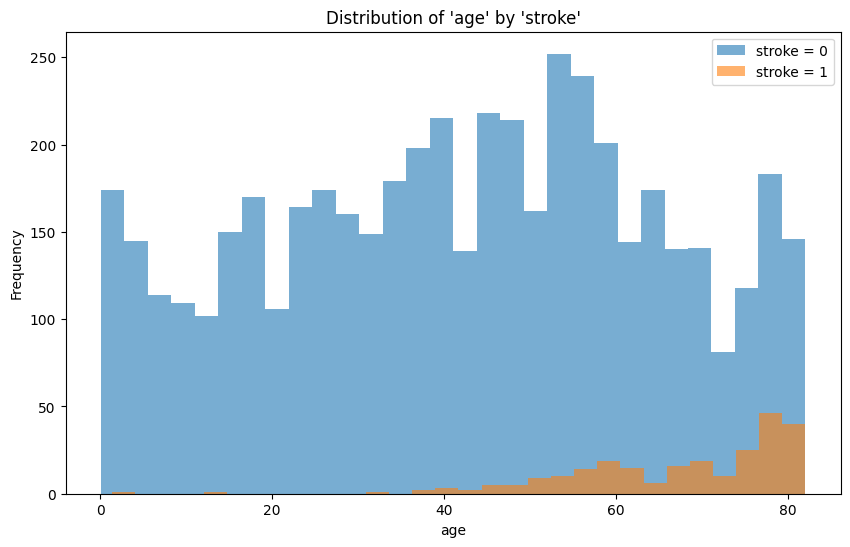

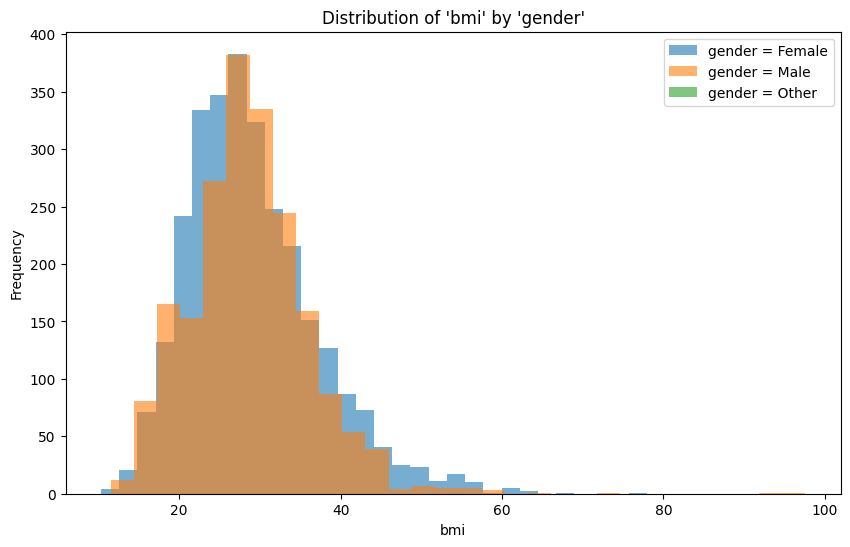

Possible column mix-up:
 - 'stroke' has only 2 unique values (looks categorical)
 - 'age' has 104 unique values (looks continuous)
Swap the arguments and try again.


In [66]:
# 1) age by stroke (0 vs 1)
plot_histograms_by_category(stroke_df, 'age', 'stroke')

# 2) BMI by Gender
plot_histograms_by_category(stroke_df, 'bmi', 'gender')

# 3) should print a useful message and return None
plot_histograms_by_category(stroke_df, 'stroke', 'age')


**Problem 9: Analyzing Group-wise Statistics with groupby**

In [73]:
import pandas as pd

def calculate_stroke_prevalence(df, group_by_cols, cat_threshold=10):
    # --- Edge case: group_by_cols must be list-like and columns must exist ---
    if not isinstance(group_by_cols, (list, tuple)) or len(group_by_cols) == 0:
        print("group_by_cols must be a non-empty list of column names.")
        return None

    missing = [c for c in group_by_cols if c not in df.columns]
    if missing:
        print(f"Column(s) not found in DataFrame: {missing}")
        return None

    # --- Edge case: grouping columns must be categorical (heuristic) ---
    # Treat as categorical if nunique <= cat_threshold OR dtype is object/category/bool
    non_categorical = []
    for c in group_by_cols:
        nunique = df[c].nunique(dropna=True)
        dtype = df[c].dtype

        looks_categorical = (
            nunique <= cat_threshold
            or pd.api.types.is_object_dtype(dtype)
            or pd.api.types.is_categorical_dtype(dtype)
            or pd.api.types.is_bool_dtype(dtype)
        )

        if not looks_categorical:
            non_categorical.append(c)

    if non_categorical:
      print(f"Non-categorical column(s) provided for grouping: {non_categorical}")
    return None

In [74]:
# 1) grouped by smoking_status
print(calculate_stroke_prevalence(stroke_df, ['smoking_status']))

# 2) grouped by ever_married and work_type
print(calculate_stroke_prevalence(stroke_df, ['ever_married', 'work_type']))

# 3) grouped by age (should trigger non-categorical edge case)
print(calculate_stroke_prevalence(stroke_df, ['age']))

# 4) grouped by residence_type (wrong capitalization; should trigger "not found")
print(calculate_stroke_prevalence(stroke_df, ['residence_type']))

None
None
Non-categorical column(s) provided for grouping: ['age']
None
Column(s) not found in DataFrame: ['residence_type']
None


/tmp/ipython-input-1013159373.py:24: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(dtype)


In [76]:
res = calculate_stroke_prevalence(stroke_df, ['smoking_status'])
if res is not None:
    print(res.sort_values('stroke_prevalence', ascending=False))

**Problem 10: Building a Preprocessing Pipeline for Analysis**

In [77]:
import pandas as pd

def preprocess_for_analysis(df, cols_to_impute, cols_to_scale, cols_to_encode, cols_to_drop):
    # 1) copy to avoid modifying original
    out = df.copy()

    # 2) drop specified columns (ignore if some missing)
    out = out.drop(columns=cols_to_drop, errors='ignore')

    # 3) impute missing values with mean (numeric)
    for col in cols_to_impute:
        if col not in out.columns:
            continue
        # coerce to numeric just in case (won't break if already numeric)
        out[col] = pd.to_numeric(out[col], errors='coerce')
        out[col] = out[col].fillna(out[col].mean())

    # 4) standard scale specified columns -> create new *_scaled columns, then drop originals
    for col in cols_to_scale:
        if col not in out.columns:
            continue
        out[col] = pd.to_numeric(out[col], errors='coerce')

        mean = out[col].mean()
        std = out[col].std()

        # avoid divide-by-zero if a column is constant
        if pd.isna(std) or std == 0:
            out[f"{col}_scaled"] = 0.0
        else:
            out[f"{col}_scaled"] = (out[col] - mean) / std

        out = out.drop(columns=[col])

    # 5) one-hot encode specified categorical columns (drop_first=True)
    # Only encode columns that still exist
    encode_cols = [c for c in cols_to_encode if c in out.columns]
    if encode_cols:
        dummies = pd.get_dummies(out[encode_cols], drop_first=True)
        out = out.drop(columns=encode_cols)
        out = out.join(dummies)

    return out

In [78]:
# Lists from the prompt
impute_list = ['bmi']  # bmi has NaNs in this dataset
scale_list = ['age', 'avg_glucose_level', 'bmi']
encode_list = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
drop_list = ['id', 'location_code']

processed_df = preprocess_for_analysis(stroke_df, impute_list, scale_list, encode_list, drop_list)

display(processed_df.head())
processed_df.info()

,hypertension,heart_disease,stroke,cardiovascular_disease,age_scaled,avg_glucose_level_scaled,bmi_scaled,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,0,1,1,1,1.051331,2.706111,1.001136e+00,True,False,True,False,True,False,False,True,True,False,False
1,0,0,1,0,0.785993,2.121351,4.615102e-16,False,False,True,False,False,True,False,False,False,True,False
2,0,1,1,1,1.626231,-0.005028,4.685314e-01,True,False,True,False,True,False,False,False,False,True,False
3,0,0,1,0,0.255317,1.437217,7.153482e-01,False,False,True,False,True,False,False,True,False,False,True
4,1,0,1,1,1.582008,1.501038,-6.356489e-01,False,False,True,False,False,True,False,False,False,True,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hypertension                    5110 non-null   int64  
 1   heart_disease                   5110 non-null   int64  
 2   stroke                          5110 non-null   int64  
 3   cardiovascular_disease          5110 non-null   int64  
 4   age_scaled                      5110 non-null   float64
 5   avg_glucose_level_scaled        5110 non-null   float64
 6   bmi_scaled                      5110 non-null   float64
 7   gender_Male                     5110 non-null   bool   
 8   gender_Other                    5110 non-null   bool   
 9   ever_married_Yes                5110 non-null   bool   
 10  work_type_Never_worked          5110 non-null   bool   
 11  work_type_Private               5110 non-null   bool   
 12  work_type_Self-employed         51

**Problem 11: Joins in Pandas with the merge method.**

In [79]:
merged_df = stroke_df.merge(
    location_df,
    how='left',
    on='location_code'
)

display(merged_df.head())

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,location_code,cardiovascular_disease,city,state
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,143,1,Miami,FL
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,116,0,Indianapolis,IN
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,145,1,Minneapolis,MN
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,185,0,Glendale,AZ
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,159,1,Lexington,KY


In [80]:
print(merged_df.shape)
print(stroke_df.shape)

(5110, 16)
(5110, 14)


In [81]:
merged_df[['location_code', 'city', 'state']].head()

,location_code,city,state
0,143,Miami,FL
1,116,Indianapolis,IN
2,145,Minneapolis,MN
3,185,Glendale,AZ
4,159,Lexington,KY


**Problem 12: Introduction to SQL with DuckDB**

In [82]:
import duckdb

In [83]:
sql_query = """
SELECT *
FROM stroke_df AS s
LEFT JOIN location_df AS l
ON s.location_code = l.location_code
WHERE l.state = 'NY'
"""

In [84]:
sql_result_df = duckdb.query(sql_query).to_df()

In [85]:
display(sql_result_df.head())

print("Unique states in result:")
print(sql_result_df['state'].unique())

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,location_code,cardiovascular_disease,location_code_1,city,state
0,37937,Female,75.0,0,1,No,Self-employed,Urban,109.78,NaN,Unknown,1,181,1,181,Buffalo,NY
1,17004,Female,70.0,0,0,Yes,Private,Urban,221.58,47.5,never smoked,1,181,0,181,Buffalo,NY
2,56841,Male,58.0,0,1,Yes,Private,Rural,240.59,31.4,smokes,1,100,1,100,New York,NY
3,20426,Female,78.0,1,0,No,Private,Urban,203.87,45.7,never smoked,1,100,1,100,New York,NY
4,66767,Female,67.0,0,0,Yes,Govt_job,Rural,94.61,28.4,smokes,0,100,0,100,New York,NY


Unique states in result:
['NY']
